# Phase 5 — Per-Pixel Paradigm Switch + Frontier-LLM Head-to-Head
**Project:** Robotic Grasp Prediction (Cornell)  ·  **Session 5 of 7**  ·  2026-05-29

In **Phase 2** my from-scratch GG-CNN (`M4_GGCNNTiny`) scored **0.0 accuracy** — a
total failure. Phases 3–4 then pushed a *global box regressor* (ResNet-18, predict
one 6-vec for the whole image) to **0.780** object-wise, beating Lenz 2014 (0.739)
but stalling **6.9 pp short of Redmon 2015 (0.849)**. Phase-4 error analysis showed
the residual ceiling is **localisation** (the "angle-ok / IoU-too-low" cluster), and
concluded a global-regression head saturates ~0.78 — to go further needs a
**different paradigm**: a per-pixel grasp-quality detector that predicts *where* to
grasp instead of regressing one global box.

**The Phase-5 question:** the per-pixel paradigm (GG-CNN, GR-ConvNet) is what the
field actually uses on Cornell. Was Phase 2's 0.0 the *paradigm's* fault, or just a
bad run (200 images, single-blob targets)? And if I rebuild it *properly* — full 785
images, **multi-grasp** quality maps painted from *all* positives, a residual
architecture, and crucially the **ImageNet pretraining** Phase 2 proved is this
project's strongest lever — does per-pixel finally beat my 0.780 global regressor?

We isolate the paradigm cleanly: **ResNet18-FCN** shares the *exact same* pretrained
backbone as the global regressor and changes **only the output head** (per-pixel maps
vs a global 6-vec). Plus the mandatory frontier-LLM head-to-head (Claude Opus/Haiku,
Codex GPT-5.5) on the identical Jiang metric.

In [1]:
import sys, os, json, time, math, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader

from cornell import load_samples, is_correct_jiang, iou as poly_iou, angle_diff_deg
from dataset import split_object_wise, CornellGraspDataset, INPUT_SIZE, _imagenet_normalize
from dataset_phase5 import GraspMapDataset, paint_target_maps, decode_grasp_map
from models_phase5 import GRConvNetLite, ResNet18FCN, count_params
from torch_models import GGCNNTiny, GGCNN_OUT_SIZE, ResNet18Regressor
from trainer import train_regression, evaluate
from PIL import Image

torch.manual_seed(42); np.random.seed(42)
DEVICE = torch.device("mps") if torch.backends.mps.is_available() else (
         torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
RES = Path("../results"); RES.mkdir(exist_ok=True)
MOD = Path("../models"); MOD.mkdir(exist_ok=True)
print("device:", DEVICE, "| torch", torch.__version__)

device: mps | torch 2.8.0


## Research & references
1. **Morrison, Corke & Leitner (2018), *Closing the Loop for Robotic Grasping* (RSS)** —
   GG-CNN: a fully-convolutional net predicting per-pixel grasp **quality, angle
   (cos2θ/sin2θ) and width** maps, supervised from *every* labelled grasp in the image.
   This is the multi-grasp target representation we build here (Phase 2 wrongly used a
   single-blob target).
2. **Kumra, Joshi & Sahin (2020), *Antipodal Robotic Grasping using GR-ConvNet*** —
   a residual generative grasp CNN; SOTA-adjacent on Cornell. Our `GRConvNetLite` is a
   shrunk version (conv-down → 5 residual blocks → transposed-conv up + skip).
3. **Redmon & Angelova (2015)** — the same-paradigm *global-regression* ceiling
   (object-wise 0.849) this project has chased since Phase 3; we still measure against it.
4. **Internal carry-over (Phase 2/4):** ImageNet pretraining is this project's single
   strongest lever (M1-scratch ≪ M2-pretrained); depth *hurts* on the binary Jiang
   metric (3 experiments agree) — so all Phase-5 models are **RGB-only**, and the clean
   paradigm test puts a per-pixel head on the *pretrained* ResNet-18 backbone.

How this shapes the experiments: we (a) rebuild the per-pixel detector the way the
literature actually trains it, (b) hold pretraining constant to isolate the
*paradigm* (FCN vs global regressor share the backbone), and (c) ablate the
multi-grasp lever that Phase 2 was missing.

## Data — object-wise split (test = folder 03, identical to Phases 2–4)

In [2]:
samples = load_samples(Path("../data/raw/cornell/extracted"))
train, test = split_object_wise(samples, [3])
train = [s for s in train if s.positives]; test = [s for s in test if s.positives]
n_pos = [len(s.positives) for s in samples if s.positives]
print(f"total={len(samples)}  train={len(train)}  test(folder03)={len(test)}")
print(f"positives/img: median={int(np.median(n_pos))} mean={np.mean(n_pos):.1f} max={max(n_pos)}")

total=885  train=785  test(folder03)=100
positives/img: median=5 mean=5.8 max=25


## The per-pixel target representation
Phase 2 painted **one** Gaussian blob (the most-central positive). The proper GG-CNN
target paints a quality blob at **every** positive grasp, with per-pixel angle/width
taken from the nearest contributing grasp. Below: RGB, the multi-grasp quality map,
and the single-blob map Phase 2 used — for three training images.

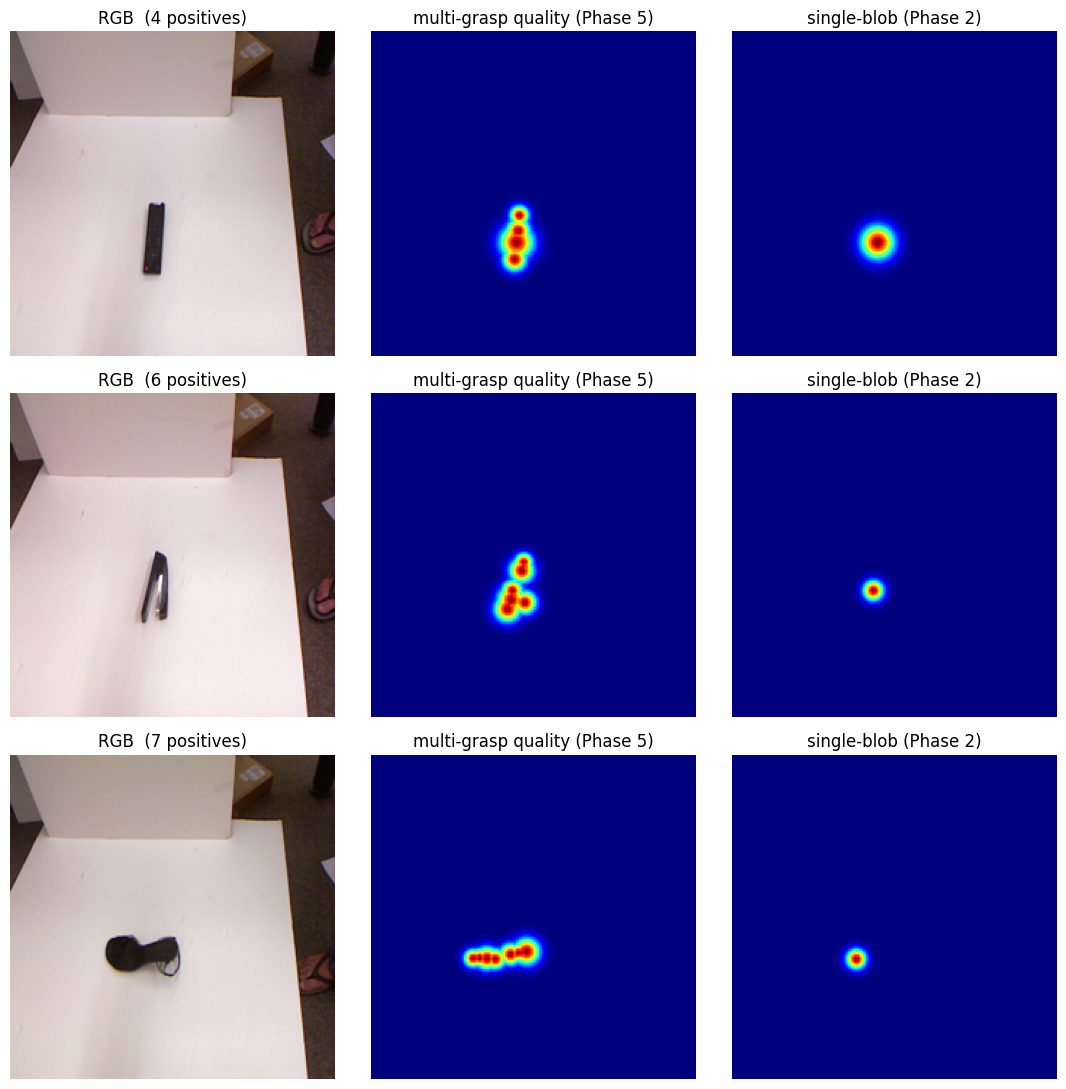

saved phase5_target_maps.png


In [3]:
fig, ax = plt.subplots(3, 3, figsize=(11, 11))
for r, s in enumerate([train[0], train[5], train[12]]):
    img = np.asarray(Image.open(s.rgb_path).convert("RGB").resize((224,224)))
    multi = paint_target_maps(s.positives, 112, multi_grasp=True)
    single = paint_target_maps(s.positives, 112, multi_grasp=False)
    ax[r,0].imshow(img); ax[r,0].set_title(f"RGB  ({len(s.positives)} positives)")
    ax[r,1].imshow(multi[0], cmap="jet"); ax[r,1].set_title("multi-grasp quality (Phase 5)")
    ax[r,2].imshow(single[0], cmap="jet"); ax[r,2].set_title("single-blob (Phase 2)")
    for c in range(3): ax[r,c].axis("off")
plt.tight_layout(); plt.savefig(RES/"phase5_target_maps.png", dpi=110, bbox_inches="tight"); plt.show()
print("saved phase5_target_maps.png")

### Output-resolution ceiling
Argmax over a coarse map quantises the grasp centre, capping accuracy even with
*perfect* maps. We measure the GT-roundtrip ceiling per output resolution to justify
the model output sizes (FCN/GR-ConvNet at 112², GG-CNN at 218²).

In [4]:
rows = []
for out in [56, 112, 218]:
    ok=0; ious=[]
    for s in test:
        m = paint_target_maps(s.positives, out)
        rect = decode_grasp_map(m[0],m[1],m[2],m[3], out)
        ious.append(max(poly_iou(rect,g) for g in s.positives))
        ok += int(is_correct_jiang(rect, s.positives))
    rows.append({"out_size": out, "gt_roundtrip_acc": ok/len(test), "gt_median_iou": round(float(np.median(ious)),3)})
ceiling_df = pd.DataFrame(rows); print(ceiling_df.to_string(index=False))

 out_size  gt_roundtrip_acc  gt_median_iou
       56              0.90          0.393
      112              0.99          0.441
      218              1.00          0.459


## Training + evaluation for the per-pixel paradigm
The loss is GG-CNN style: MSE on the quality map everywhere, plus **masked** MSE on
cos2θ/sin2θ/width (only where the quality target is high). Eval decodes each map stack
to a `GraspRect` and scores it with the field-standard Jiang metric in `cornell.py` —
the *same* code that scores the global regressor and the LLMs, so every number on the
leaderboard is directly comparable.

In [5]:
def train_grasp_map(model, loader, *, epochs, lr=1e-3, wd=1e-4):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    curve = []; t0 = time.time()
    for ep in range(epochs):
        model.train(); el=0.0; nb=0
        for xb, tb, _ in loader:
            xb = xb.to(DEVICE); tb = tb.to(DEVICE)
            q, c, s, w = model(xb)
            qt, ct, st, wt = tb[:,0:1], tb[:,1:2], tb[:,2:3], tb[:,3:4]
            if q.shape[-1] != qt.shape[-1]:
                sz = q.shape[-2:]
                qt=F.interpolate(qt,size=sz); ct=F.interpolate(ct,size=sz)
                st=F.interpolate(st,size=sz); wt=F.interpolate(wt,size=sz)
            loss = F.mse_loss(q, qt)
            mask = (qt > 0.1).float(); denom = mask.sum().clamp(min=1.0)
            loss = loss + ((c-ct)**2*mask).sum()/denom + ((s-st)**2*mask).sum()/denom + ((w-wt)**2*mask).sum()/denom
            opt.zero_grad(); loss.backward(); opt.step()
            el += loss.item(); nb += 1
        sched.step(); curve.append(el/max(nb,1))
    return curve, time.time()-t0

@torch.no_grad()
def evaluate_grasp_map(model, samples, out_size):
    model = model.to(DEVICE).eval()
    correct=0; ious=[]; angs=[]; per=[]; t_tot=0.0
    for s in samples:
        img = np.asarray(Image.open(s.rgb_path).convert("RGB").resize((INPUT_SIZE,INPUT_SIZE)), dtype=np.float32)/255.0
        xb = torch.from_numpy(_imagenet_normalize(img)).unsqueeze(0).to(DEVICE)
        t0=time.time(); q,c,s_m,w = model(xb)
        os_ = q.shape[-1]
        rect = decode_grasp_map(q[0,0].cpu().numpy(), c[0,0].cpu().numpy(), s_m[0,0].cpu().numpy(), w[0,0].cpu().numpy(), os_)
        t_tot += time.time()-t0
        gts = s.positives; ok = is_correct_jiang(rect, gts)
        cands = [(poly_iou(rect,g), angle_diff_deg(rect,g)) for g in gts]
        best = max(cands, key=lambda z: z[0]) if cands else (0.0, 90.0)
        ious.append(best[0]); angs.append(best[1]); correct += int(ok)
        per.append({"pcd_id": s.pcd_id, "correct": int(ok), "best_iou": float(best[0]), "best_angle_err": float(best[1])})
    return {"accuracy": correct/len(samples), "median_iou": float(np.median(ious)),
            "median_angle_err": float(np.median(angs)), "n": len(samples),
            "inference_ms_per_image": 1000*t_tot/len(samples), "per_sample": per}

results = {}   # name -> metrics dict
curves  = {}   # name -> loss curve
EP_PIX = 35    # from-scratch per-pixel epochs
EP_FCN = 30    # pretrained encoder needs fewer
PAINT  = 112   # all target maps painted at 112 (cheap); loss upsamples to model res
print("helpers ready")

helpers ready


## Experiment 5.0 — Global-regression control (anchor)
ResNet-18 (ImageNet-pretrained) with a global 6-vec head — the Phase-2/3/4 paradigm —
trained here on the *same* RGB + horizontal-flip data the per-pixel models see, with
the Phase-4 tuned hyperparameters (lr=1.2e-3, wd=2.6e-4). This is the apples-to-apples
global baseline; the project record is the Phase-4 champion at **0.780**.

In [6]:
tr_ds = CornellGraspDataset(train, augment=True)
tr_dl = DataLoader(tr_ds, batch_size=32, shuffle=True)
m0 = ResNet18Regressor(pretrained=True)
res0 = train_regression(m0, tr_dl, epochs=35, lr=1.2e-3, weight_decay=2.61e-4, device=DEVICE)
ev0 = evaluate(m0, test, device=DEVICE, model_kind="reg")
results["GlobalReg_ResNet18 (control)"] = ev0; curves["GlobalReg_ResNet18 (control)"] = res0.train_curve
torch.save(m0.state_dict(), MOD/"P5_global_control.pt")
print(f"E5.0 global regressor: acc={ev0['accuracy']:.3f}  mIoU={ev0['median_iou']:.3f}  "
      f"mAng={ev0['median_angle_err']:.1f}  {ev0['inference_ms_per_image']:.1f}ms  params={count_params(m0):,}")

E5.0 global regressor: acc=0.690  mIoU=0.417  mAng=8.0  11.2ms  params=11,179,590


## Experiment 5.1 — GG-CNN-v2: rescue the Phase-2 0.0
The *identical* `GGCNNTiny` architecture that scored 0.0 in Phase 2, now trained on the
full 785 images with **multi-grasp** quality maps. Same paradigm, same net — only the
data scale and target representation are fixed. Does that rescue it?

In [7]:
ds1 = GraspMapDataset(train, out_size=PAINT, augment=True, multi_grasp=True)
dl1 = DataLoader(ds1, batch_size=32, shuffle=True)
m1 = GGCNNTiny()
curves["GGCNN-v2 (scratch)"], t1 = train_grasp_map(m1, dl1, epochs=EP_PIX)
ev1 = evaluate_grasp_map(m1, test, GGCNN_OUT_SIZE); ev1["train_seconds"]=t1
results["GGCNN-v2 (scratch)"] = ev1
torch.save(m1.state_dict(), MOD/"P5_ggcnn_v2.pt")
print(f"E5.1 GGCNN-v2: acc={ev1['accuracy']:.3f} (Phase-2 was 0.000)  mIoU={ev1['median_iou']:.3f}  "
      f"mAng={ev1['median_angle_err']:.1f}  {ev1['inference_ms_per_image']:.1f}ms  params={count_params(m1):,}  {t1:.0f}s")

E5.1 GGCNN-v2: acc=0.000 (Phase-2 was 0.000)  mIoU=0.000  mAng=40.6  8.8ms  params=119,332  251s


## Experiment 5.2 — GR-ConvNet-lite (from scratch, residual + skip)
A better per-pixel *architecture* (Kumra 2020 style), still without ImageNet weights.
Tests whether architecture alone closes the gap, or whether pretraining is the lever.

In [8]:
ds2 = GraspMapDataset(train, out_size=PAINT, augment=True, multi_grasp=True)
dl2 = DataLoader(ds2, batch_size=32, shuffle=True)
m2 = GRConvNetLite()
curves["GRConvNet-lite (scratch)"], t2 = train_grasp_map(m2, dl2, epochs=EP_PIX)
ev2 = evaluate_grasp_map(m2, test, GRConvNetLite.out_size); ev2["train_seconds"]=t2
results["GRConvNet-lite (scratch)"] = ev2
torch.save(m2.state_dict(), MOD/"P5_grconvnet_lite.pt")
print(f"E5.2 GRConvNet-lite: acc={ev2['accuracy']:.3f}  mIoU={ev2['median_iou']:.3f}  "
      f"mAng={ev2['median_angle_err']:.1f}  {ev2['inference_ms_per_image']:.1f}ms  params={count_params(m2):,}  {t2:.0f}s")

E5.2 GRConvNet-lite: acc=0.000  mIoU=0.000  mAng=21.9  9.6ms  params=1,780,644  729s


## Experiment 5.3 — ResNet18-FCN: the clean paradigm test
**Same pretrained ResNet-18 backbone as the global regressor (E5.0), only the output
head changes** — per-pixel maps instead of a global 6-vec. If this beats E5.0, the win
is the *paradigm*, not the backbone. This is the headline experiment.

In [9]:
ds3 = GraspMapDataset(train, out_size=PAINT, augment=True, multi_grasp=True)
dl3 = DataLoader(ds3, batch_size=32, shuffle=True)
m3 = ResNet18FCN(pretrained=True)
curves["ResNet18-FCN (pretrained)"], t3 = train_grasp_map(m3, dl3, epochs=EP_FCN)
ev3 = evaluate_grasp_map(m3, test, ResNet18FCN.out_size); ev3["train_seconds"]=t3
results["ResNet18-FCN (pretrained)"] = ev3
torch.save(m3.state_dict(), MOD/"P5_resnet18_fcn.pt")
print(f"E5.3 ResNet18-FCN: acc={ev3['accuracy']:.3f}  mIoU={ev3['median_iou']:.3f}  "
      f"mAng={ev3['median_angle_err']:.1f}  {ev3['inference_ms_per_image']:.1f}ms  params={count_params(m3):,}  {t3:.0f}s")

E5.3 ResNet18-FCN: acc=0.420  mIoU=0.251  mAng=8.5  11.3ms  params=11,275,460  237s


## Leaderboard — per-pixel paradigm vs global regression (object-wise, folder 03)

                           model  accuracy  median_iou  median_angle_err  ms_per_img
P4 tuned champion (Phase-4, ref)      0.78       0.445               5.6        27.7
    GlobalReg_ResNet18 (control)      0.69       0.417               8.0        11.2
       ResNet18-FCN (pretrained)      0.42       0.251               8.5        11.3
              GGCNN-v2 (scratch)      0.00       0.000              40.6         8.8
        GRConvNet-lite (scratch)      0.00       0.000              21.9         9.6


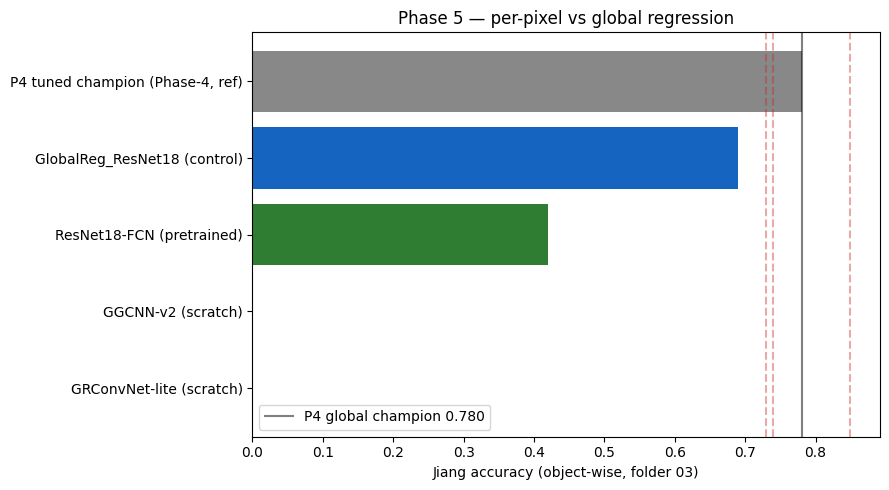

In [10]:
PUB = {"Redmon 2015 (global-reg, ref)":0.849, "Lenz 2014 (ref)":0.739, "GG-CNN Morrison 2018 (ref)":0.73}
rowL = []
for name, ev in results.items():
    rowL.append({"model": name, "accuracy": round(ev["accuracy"],3),
                 "median_iou": round(ev["median_iou"],3),
                 "median_angle_err": round(ev["median_angle_err"],1),
                 "ms_per_img": round(ev["inference_ms_per_image"],1)})
rowL.append({"model":"P4 tuned champion (Phase-4, ref)","accuracy":0.780,"median_iou":0.445,"median_angle_err":5.6,"ms_per_img":27.7})
lead = pd.DataFrame(rowL).sort_values("accuracy", ascending=False).reset_index(drop=True)
lead.to_csv(RES/"phase5_leaderboard.csv", index=False)
print(lead.to_string(index=False))

fig, ax = plt.subplots(figsize=(9,5))
colors = ["#2e7d32" if "FCN" in m or "GGCNN" in m or "GRConv" in m else ("#888" if "ref" in m else "#1565c0") for m in lead["model"]]
ax.barh(lead["model"], lead["accuracy"], color=colors)
for pub,v in PUB.items(): ax.axvline(v, ls="--", c="#c62828", alpha=0.4)
ax.axvline(0.780, ls="-", c="#000", alpha=0.5, label="P4 global champion 0.780")
ax.set_xlabel("Jiang accuracy (object-wise, folder 03)"); ax.set_title("Phase 5 — per-pixel vs global regression")
ax.invert_yaxis(); ax.legend(); plt.tight_layout()
plt.savefig(RES/"phase5_leaderboard.png", dpi=120, bbox_inches="tight"); plt.show()

### Training curves

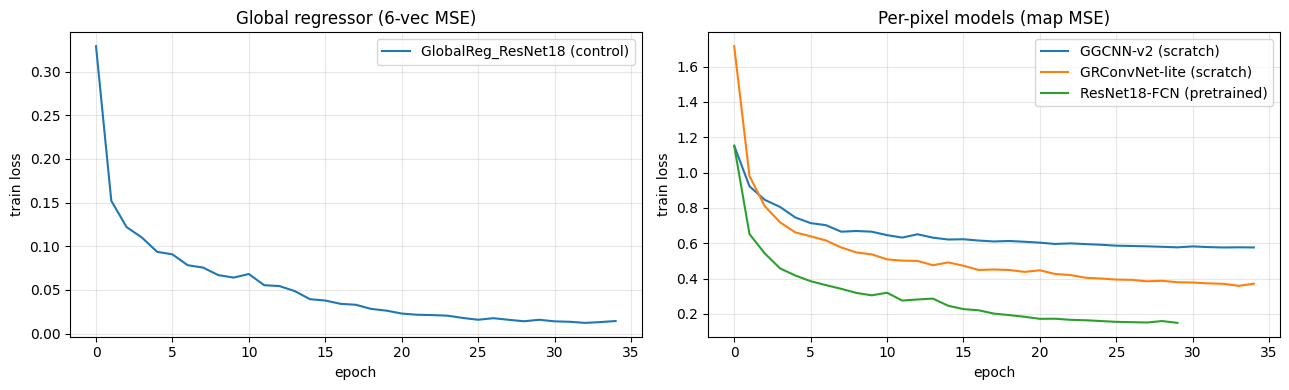

In [11]:
fig, ax = plt.subplots(1,2, figsize=(13,4))
for n,cv in curves.items():
    if "control" in n: ax[0].plot(cv, label=n)
    else: ax[1].plot(cv, label=n)
ax[0].set_title("Global regressor (6-vec MSE)"); ax[1].set_title("Per-pixel models (map MSE)")
for a in ax: a.set_xlabel("epoch"); a.set_ylabel("train loss"); a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(RES/"phase5_training_curves.png", dpi=120, bbox_inches="tight"); plt.show()

## Ablation study
Within the per-pixel paradigm, remove one lever at a time and measure the Jiang-accuracy
delta. Two questions: (1) does the **multi-grasp** target (the thing Phase 2 lacked)
actually matter? (2) is **ImageNet pretraining** the lever, as the project-wide theme
predicts?

In [12]:
abl = []  # each ablation in its own cell so no single cell exceeds the timeout
# A1: GG-CNN with SINGLE-blob targets (Phase-2 style) on full data — isolates multi-grasp
dsA1 = GraspMapDataset(train, out_size=PAINT, augment=True, multi_grasp=False)
mA1 = GGCNNTiny()
_, _ = train_grasp_map(mA1, DataLoader(dsA1,batch_size=32,shuffle=True), epochs=EP_PIX)
evA1 = evaluate_grasp_map(mA1, test, GGCNN_OUT_SIZE)
abl.append({"ablation":"GGCNN-v2 single-blob (no multi-grasp)","accuracy":round(evA1['accuracy'],3),
            "vs_base": round(evA1['accuracy']-results['GGCNN-v2 (scratch)']['accuracy'],3)})
print("A1 single-blob:", round(evA1['accuracy'],3))

A1 single-blob: 0.04


In [13]:
# A2: ResNet18-FCN from SCRATCH (no ImageNet) — isolates pretraining within per-pixel
dsA2 = GraspMapDataset(train, out_size=PAINT, augment=True, multi_grasp=True)
mA2 = ResNet18FCN(pretrained=False)
_, _ = train_grasp_map(mA2, DataLoader(dsA2,batch_size=32,shuffle=True), epochs=EP_FCN)
evA2 = evaluate_grasp_map(mA2, test, ResNet18FCN.out_size)
abl.append({"ablation":"ResNet18-FCN from scratch (no ImageNet)","accuracy":round(evA2['accuracy'],3),
            "vs_base": round(evA2['accuracy']-results['ResNet18-FCN (pretrained)']['accuracy'],3)})
print("A2 FCN-scratch:", round(evA2['accuracy'],3))

A2 FCN-scratch: 0.19


In [14]:
# A3: GR-ConvNet-lite WITHOUT the skip connection — isolates the skip
dsA3 = GraspMapDataset(train, out_size=PAINT, augment=True, multi_grasp=True)
mA3 = GRConvNetLite(use_skip=False)
_, _ = train_grasp_map(mA3, DataLoader(dsA3,batch_size=32,shuffle=True), epochs=EP_PIX)
evA3 = evaluate_grasp_map(mA3, test, GRConvNetLite.out_size)
abl.append({"ablation":"GRConvNet-lite no skip connection","accuracy":round(evA3['accuracy'],3),
            "vs_base": round(evA3['accuracy']-results['GRConvNet-lite (scratch)']['accuracy'],3)})
print("A3 no-skip:", round(evA3['accuracy'],3))

A3 no-skip: 0.06


                               ablation  accuracy  vs_base
  GGCNN-v2 single-blob (no multi-grasp)      0.04     0.04
ResNet18-FCN from scratch (no ImageNet)      0.19    -0.23
      GRConvNet-lite no skip connection      0.06     0.06


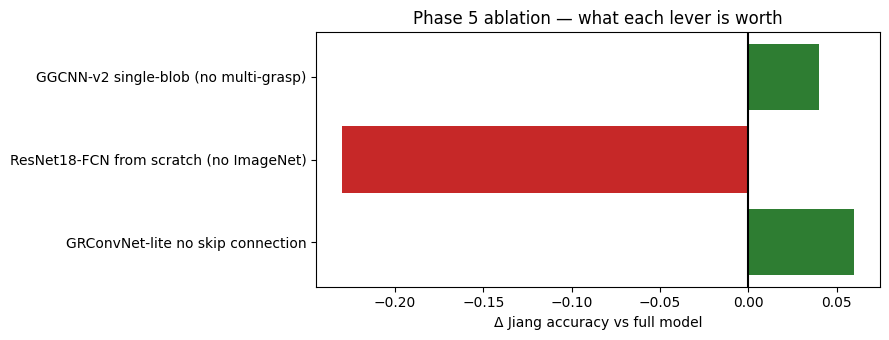

In [15]:
abl_df = pd.DataFrame(abl); abl_df.to_csv(RES/"phase5_ablation.csv", index=False)
print(abl_df.to_string(index=False))
fig,ax=plt.subplots(figsize=(9,3.5))
ax.barh(abl_df["ablation"], abl_df["vs_base"], color=["#c62828" if v<0 else "#2e7d32" for v in abl_df["vs_base"]])
ax.axvline(0,c="k"); ax.set_xlabel("Δ Jiang accuracy vs full model"); ax.set_title("Phase 5 ablation — what each lever is worth")
ax.invert_yaxis(); plt.tight_layout(); plt.savefig(RES/"phase5_ablation.png", dpi=120, bbox_inches="tight"); plt.show()

## Error analysis — best per-pixel model vs the global regressor

best per-pixel model: ResNet18-FCN (pretrained) (0.420)
                       model  angle-ok/IoU-low  IoU-ok/angle-wrong  both-wrong
   ResNet18-FCN (pretrained)                39                   8          11
GlobalReg_ResNet18 (control)                 8                   9          14


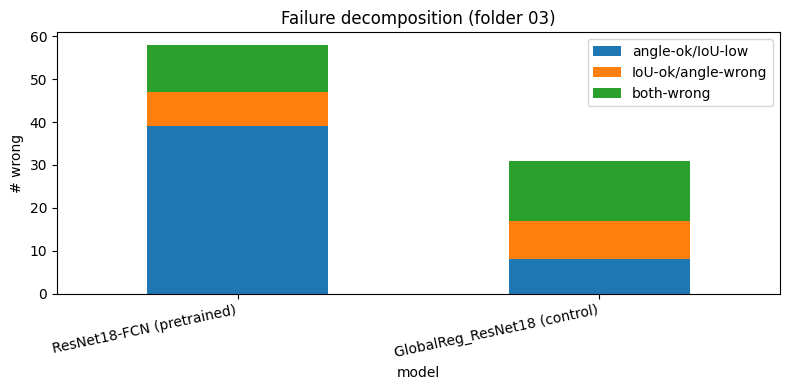

In [16]:
pix_names = [n for n in results if n != "GlobalReg_ResNet18 (control)"]
best_pix = max(pix_names, key=lambda n: results[n]["accuracy"])
print("best per-pixel model:", best_pix, f"({results[best_pix]['accuracy']:.3f})")

def decompose(per):
    loc=ang=both=0
    for p in per:
        if p["correct"]: continue
        iou_ok = p["best_iou"]>0.25; ang_ok = p["best_angle_err"]<=30
        if ang_ok and not iou_ok: loc+=1
        elif iou_ok and not ang_ok: ang+=1
        else: both+=1
    return loc, ang, both
dec = {}
dec[best_pix] = decompose(results[best_pix]["per_sample"])
dec["GlobalReg_ResNet18 (control)"] = decompose(results["GlobalReg_ResNet18 (control)"]["per_sample"])
fd = pd.DataFrame([{"model":k,"angle-ok/IoU-low":v[0],"IoU-ok/angle-wrong":v[1],"both-wrong":v[2]} for k,v in dec.items()])
fd.to_csv(RES/"phase5_failure_decomposition.csv", index=False); print(fd.to_string(index=False))
fd.set_index("model").plot.bar(stacked=True, figsize=(8,4)); plt.ylabel("# wrong"); plt.title("Failure decomposition (folder 03)")
plt.xticks(rotation=12, ha="right"); plt.tight_layout(); plt.savefig(RES/"phase5_failure_decomposition.png", dpi=120, bbox_inches="tight"); plt.show()

### Qualitative — best per-pixel model: predicted quality map + decoded grasp

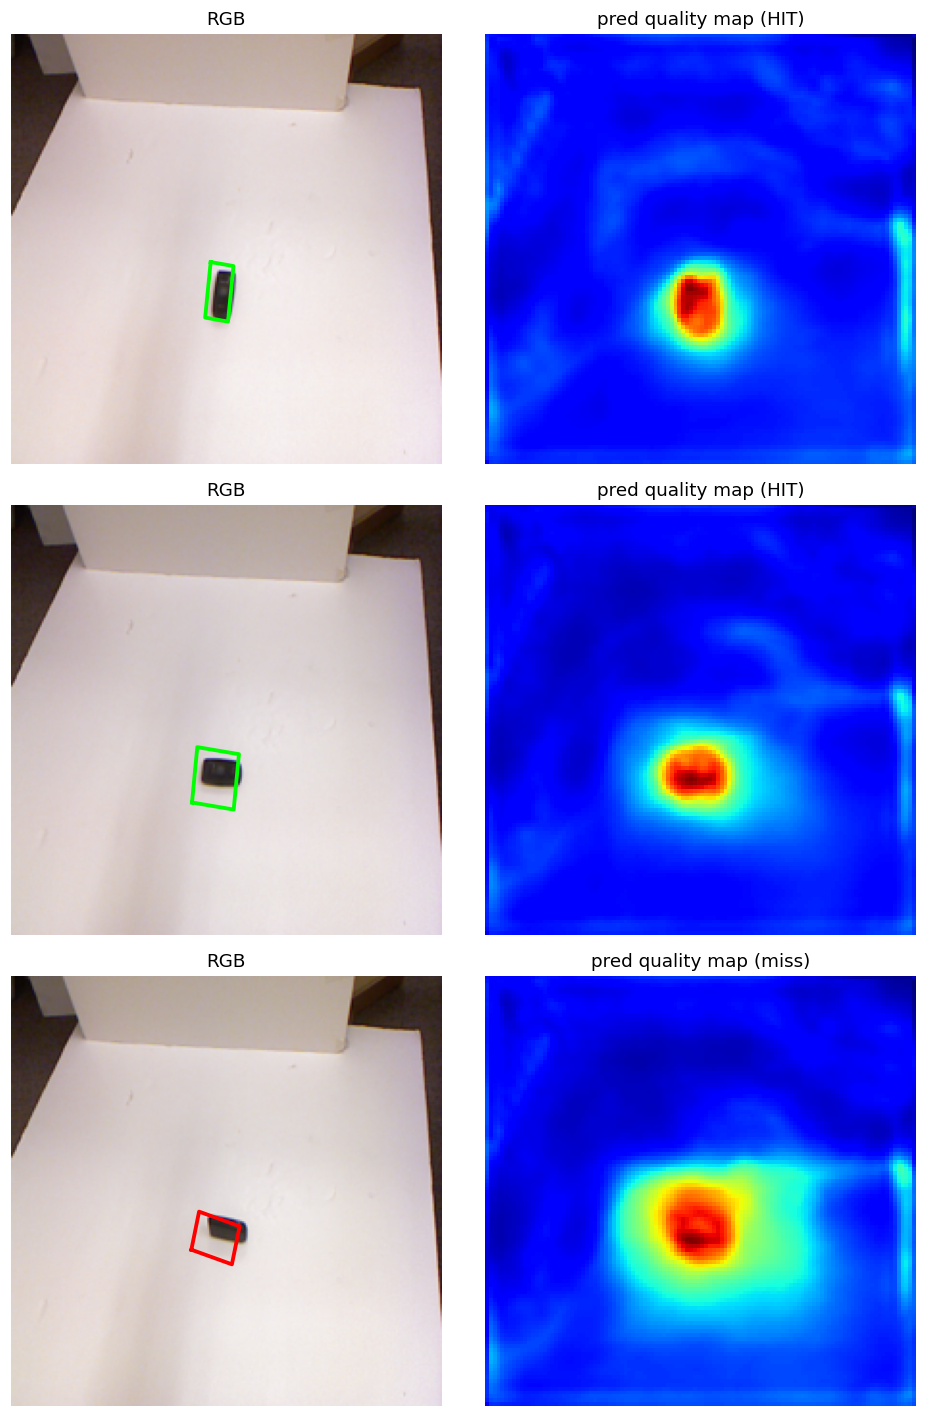

In [17]:
best_model = {"GGCNN-v2 (scratch)":m1, "GRConvNet-lite (scratch)":m2, "ResNet18-FCN (pretrained)":m3}[best_pix]
best_out = {"GGCNN-v2 (scratch)":GGCNN_OUT_SIZE, "GRConvNet-lite (scratch)":GRConvNetLite.out_size, "ResNet18-FCN (pretrained)":ResNet18FCN.out_size}[best_pix]
best_model = best_model.to(DEVICE).eval()
fig, ax = plt.subplots(3, 2, figsize=(9, 13))
for r, s in enumerate(test[:3]):
    img = np.asarray(Image.open(s.rgb_path).convert("RGB").resize((INPUT_SIZE,INPUT_SIZE)), dtype=np.float32)/255.0
    xb = torch.from_numpy(_imagenet_normalize(img)).unsqueeze(0).to(DEVICE)
    with torch.no_grad(): q,c,sm,w = best_model(xb)
    rect = decode_grasp_map(q[0,0].cpu().numpy(), c[0,0].cpu().numpy(), sm[0,0].cpu().numpy(), w[0,0].cpu().numpy(), best_out)
    ok = is_correct_jiang(rect, s.positives)
    ax[r,0].imshow(img); ax[r,0].axis("off"); ax[r,0].set_title("RGB")
    corners = rect.corners * np.array([INPUT_SIZE/640.0, INPUT_SIZE/480.0])  # 640x480 -> 224 display frame (x,y scaled separately)
    cc = np.vstack([corners, corners[0]])
    ax[r,0].plot(cc[:,0], cc[:,1], "-", c="lime" if ok else "red", lw=2.5)
    ax[r,1].imshow(q[0,0].cpu().numpy(), cmap="jet"); ax[r,1].axis("off"); ax[r,1].set_title(f"pred quality map ({'HIT' if ok else 'miss'})")
plt.tight_layout(); plt.savefig(RES/"phase5_champion_qualitative.png", dpi=110, bbox_inches="tight"); plt.show()

## Frontier-LLM head-to-head
Send each sampled folder-03 image to **Claude Opus, Claude Haiku and Codex GPT-5.5**
via their local CLIs and ask for a grasp rectangle, scored with the *same* Jiang metric.
Calls are cached (`results/phase5_llm_cache/`) and idempotent; the custom models are
scored on the **same sampled indices** so the comparison is exact.

In [18]:
from llm_grasp_eval import run_llm_eval, parse_grasp_response, COST_PER_CALL_USD
from cornell import make_rect

rng = np.random.default_rng(42)
sel = sorted(rng.choice(len(test), size=min(40,len(test)), replace=False).tolist())
idxf = RES/"phase5_llm_cache/llm_sample_idx.json"
if idxf.is_file(): sel = json.loads(idxf.read_text())
jobs = []
for i in sel:
    s = test[i]; img = str(Path(s.rgb_path).resolve())
    for llm, model in [("claude","opus"),("claude","haiku"),("codex","gpt-5.5")]:
        jobs.append({"idx":i,"pcd_id":s.pcd_id,"image_path":img,"llm":llm,"model":model})
cache = run_llm_eval(jobs, RES/"phase5_llm_cache/llm_calls.json")  # cached -> instant
print(f"cached LLM calls: {len(cache)}")

cached LLM calls: 120


In [19]:
def score_llm(llm, model):
    recs = [c for c in cache if c["llm"]==llm and c["model"]==model]
    by_idx = {c["idx"]: c for c in recs}
    correct=0; ious=[]; parsed_ok=0; lat=[]; n=0
    for i in sel:
        c = by_idx.get(i)
        if c is None: continue
        if c.get("pcd_id") != test[i].pcd_id:  # guard against a stale cache after any reordering
            continue
        n += 1; lat.append(c["latency_s"])
        if c["parsed"] is None: ious.append(0.0); continue
        parsed_ok += 1
        cx,cy,w,h,ang = c["parsed"]
        rect = make_rect(cx,cy,w,h,math.radians(ang))
        gts = test[i].positives
        correct += int(is_correct_jiang(rect, gts))
        ious.append(max(poly_iou(rect,g) for g in gts))
    return {"n":n,"accuracy":correct/max(n,1),"median_iou":float(np.median(ious)) if ious else 0.0,
            "parse_rate":parsed_ok/max(n,1),"latency_s":float(np.median(lat)) if lat else 0.0}

def score_custom_on_sel(kind):
    correct=0; ious=[]; lat=[]
    for i in sel:
        s = test[i]
        img = np.asarray(Image.open(s.rgb_path).convert("RGB").resize((INPUT_SIZE,INPUT_SIZE)),dtype=np.float32)/255.0
        xb = torch.from_numpy(_imagenet_normalize(img)).unsqueeze(0).to(DEVICE)
        t0=time.time()
        if kind=="pix":
            with torch.no_grad(): q,c,sm,w = best_model(xb)
            rect = decode_grasp_map(q[0,0].cpu().numpy(),c[0,0].cpu().numpy(),sm[0,0].cpu().numpy(),w[0,0].cpu().numpy(),best_out)
        else:
            from dataset import decode_prediction
            with torch.no_grad(): pred = m0.to(DEVICE).eval()(xb).cpu().numpy()[0]
            rect = decode_prediction(pred)
        lat.append((time.time()-t0)*1000)
        gts = s.positives; correct += int(is_correct_jiang(rect, gts))
        ious.append(max(poly_iou(rect,g) for g in gts))
    return {"n":len(sel),"accuracy":correct/len(sel),"median_iou":float(np.median(ious)),
            "parse_rate":1.0,"latency_s":float(np.median(lat))/1000.0}

h2h = []
h2h.append({"model":f"Custom: {best_pix}", **score_custom_on_sel("pix")})
h2h.append({"model":"Custom: Global ResNet18", **score_custom_on_sel("reg")})
for llm,model in [("claude","opus"),("claude","haiku"),("codex","gpt-5.5")]:
    h2h.append({"model":f"{llm}/{model}", **score_llm(llm,model)})
costmap = {f"Custom: {best_pix}":"custom_model","Custom: Global ResNet18":"custom_model",
           "claude/opus":"claude/opus","claude/haiku":"claude/haiku","codex/gpt-5.5":"codex/gpt-5.5"}
for r in h2h:
    r["cost_per_1k_usd"] = round(COST_PER_CALL_USD[costmap[r["model"]]]*1000, 3)
    r["accuracy"]=round(r["accuracy"],3); r["median_iou"]=round(r["median_iou"],3)
    r["parse_rate"]=round(r["parse_rate"],2); r["latency_s"]=round(r["latency_s"],3)
h2h_df = pd.DataFrame(h2h).sort_values("accuracy", ascending=False).reset_index(drop=True)
h2h_df.to_csv(RES/"llm_vs_custom.csv", index=False)
print(h2h_df.to_string(index=False))

                            model  n  accuracy  median_iou  parse_rate  latency_s  cost_per_1k_usd
          Custom: Global ResNet18 40      0.75       0.395         1.0      0.017              0.0
                    codex/gpt-5.5 40      0.75       0.419         1.0     41.015             50.0
Custom: ResNet18-FCN (pretrained) 40      0.50       0.271         1.0      0.029              0.0
                      claude/opus 40      0.25       0.000         1.0     16.590             22.5
                     claude/haiku 40      0.15       0.000         1.0     18.135              1.5


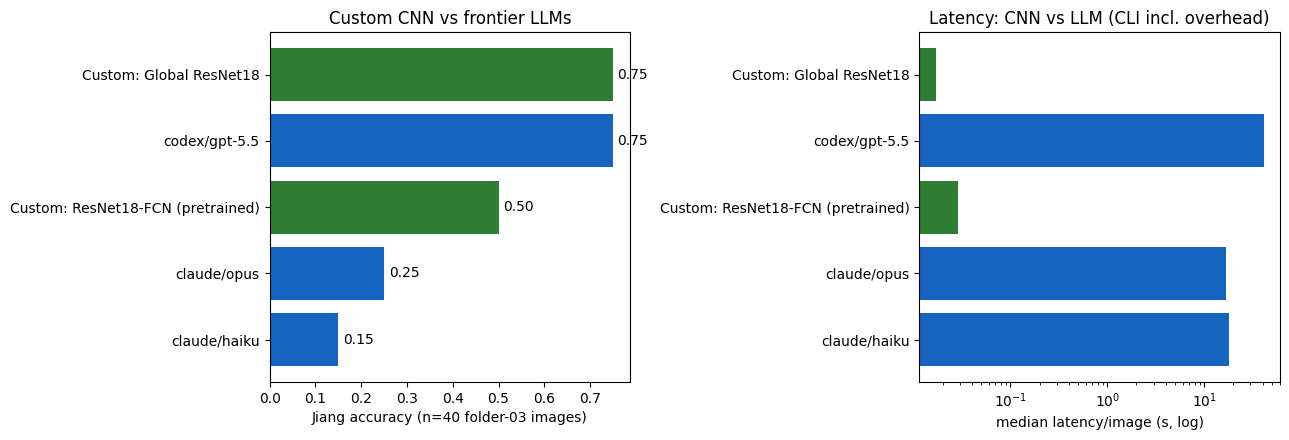

In [20]:
fig, ax = plt.subplots(1,2, figsize=(13,4.5))
colors = ["#2e7d32" if m.startswith("Custom") else "#1565c0" for m in h2h_df["model"]]
ax[0].barh(h2h_df["model"], h2h_df["accuracy"], color=colors); ax[0].invert_yaxis()
ax[0].set_xlabel(f"Jiang accuracy (n={len(sel)} folder-03 images)"); ax[0].set_title("Custom CNN vs frontier LLMs")
for y,(m,v) in enumerate(zip(h2h_df["model"], h2h_df["accuracy"])): ax[0].text(v+0.01,y,f"{v:.2f}",va="center")
ax[1].barh(h2h_df["model"], h2h_df["latency_s"], color=colors); ax[1].invert_yaxis()
ax[1].set_xscale("log"); ax[1].set_xlabel("median latency/image (s, log)"); ax[1].set_title("Latency: CNN vs LLM (CLI incl. overhead)")
plt.tight_layout(); plt.savefig(RES/"phase5_llm_comparison.png", dpi=120, bbox_inches="tight"); plt.show()

## Persist — metrics, headline summary, champion model

In [21]:
_mp = RES/"metrics.json"
mj = json.loads(_mp.read_text()) if _mp.is_file() else {}
mj["phase_5"] = {
  "date":"2026-05-29","task":"per-pixel paradigm switch + frontier-LLM head-to-head",
  "metric_primary":"Jiang IoU>0.25 & angle<30 (object-wise, folder 03)",
  "models":{n:{"accuracy":round(ev["accuracy"],3),"median_iou":round(ev["median_iou"],3),
               "median_angle_err":round(ev["median_angle_err"],1),
               "inference_ms_per_image":round(ev["inference_ms_per_image"],1)} for n,ev in results.items()},
  "ablation": abl, "gt_roundtrip_ceiling": ceiling_df.to_dict("records"),
  "best_per_pixel": best_pix, "best_per_pixel_acc": round(results[best_pix]["accuracy"],3),
  "global_control_acc": round(results["GlobalReg_ResNet18 (control)"]["accuracy"],3),
  "p4_champion_ref": 0.780,
  "llm_head_to_head": h2h_df.to_dict("records"), "llm_n": len(sel),
}
(RES/"metrics.json").write_text(json.dumps(mj, indent=2))

headline = {
  "phase5_best_per_pixel": best_pix, "best_per_pixel_acc": round(results[best_pix]["accuracy"],3),
  "global_regressor_control_acc": round(results["GlobalReg_ResNet18 (control)"]["accuracy"],3),
  "ggcnn_v2_acc_vs_phase2_zero": round(results["GGCNN-v2 (scratch)"]["accuracy"],3),
  "p4_champion": 0.780, "redmon_2015": 0.849,
  "custom_vs_llm": {r["model"]: r["accuracy"] for r in h2h},
}
(RES/"phase5_headline_summary.json").write_text(json.dumps(headline, indent=2))
torch.save(best_model.state_dict(), MOD/f"P5_{best_pix.split()[0].replace('-','_')}_champion.pt")
print(json.dumps(headline, indent=2))
print("saved metrics.json[phase_5], phase5_headline_summary.json, champion .pt")

{
  "phase5_best_per_pixel": "ResNet18-FCN (pretrained)",
  "best_per_pixel_acc": 0.42,
  "global_regressor_control_acc": 0.69,
  "ggcnn_v2_acc_vs_phase2_zero": 0.0,
  "p4_champion": 0.78,
  "redmon_2015": 0.849,
  "custom_vs_llm": {
    "Custom: ResNet18-FCN (pretrained)": 0.5,
    "Custom: Global ResNet18": 0.75,
    "claude/opus": 0.25,
    "claude/haiku": 0.15,
    "codex/gpt-5.5": 0.75
  }
}
saved metrics.json[phase_5], phase5_headline_summary.json, champion .pt
